In [2]:
import numpy as np 
import pandas as pd 

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from sklearn.utils import shuffle

from scipy.io import loadmat

import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib import colormaps

from numpy.random import sample as sample


In [3]:
doc=pd.read_csv("hashtag_donaldtrump.csv",lineterminator='\n')

In [4]:
doc.head(n=5)

,created_at,tweet_id,tweet,likes,retweet_count,source,user_id,user_name,user_screen_name,user_description,...,user_followers_count,user_location,lat,long,city,country,continent,state,state_code,collected_at
0,2020-10-15 00:00:01,1.316529e+18,#Elecciones2020 | En #Florida: #JoeBiden dice ...,0.0,0.0,TweetDeck,3.606665e+08,El Sol Latino News,elsollatinonews,🌐 Noticias de interés para latinos de la costa...,...,1860.0,"Philadelphia, PA / Miami, FL",25.774270,-80.193660,NaN,United States of America,North America,Florida,FL,2020-10-21 00:00:00
1,2020-10-15 00:00:01,1.316529e+18,"Usa 2020, Trump contro Facebook e Twitter: cop...",26.0,9.0,Social Mediaset,3.316176e+08,Tgcom24,MediasetTgcom24,Profilo ufficiale di Tgcom24: tutte le notizie...,...,1067661.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2020-10-21 00:00:00.373216530
2,2020-10-15 00:00:02,1.316529e+18,"#Trump: As a student I used to hear for years,...",2.0,1.0,Twitter Web App,8.436472e+06,snarke,snarke,"Will mock for food! Freelance writer, blogger,...",...,1185.0,Portland,45.520247,-122.674195,Portland,United States of America,North America,Oregon,OR,2020-10-21 00:00:00.746433060
3,2020-10-15 00:00:02,1.316529e+18,2 hours since last tweet from #Trump! Maybe he...,0.0,0.0,Trumpytweeter,8.283556e+17,Trumpytweeter,trumpytweeter,"If he doesn't tweet for some time, should we b...",...,32.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2020-10-21 00:00:01.119649591
4,2020-10-15 00:00:08,1.316529e+18,You get a tie! And you get a tie! #Trump ‘s ra...,4.0,3.0,Twitter for iPhone,4.741380e+07,Rana Abtar - رنا أبتر,Ranaabtar,"Washington Correspondent, Lebanese-American ,c...",...,5393.0,Washington DC,38.894992,-77.036558,Washington,United States of America,North America,District of Columbia,DC,2020-10-21 00:00:01.492866121


In [5]:
doc.info

<bound method DataFrame.info of                  created_at      tweet_id  \
0       2020-10-15 00:00:01  1.316529e+18   
1       2020-10-15 00:00:01  1.316529e+18   
2       2020-10-15 00:00:02  1.316529e+18   
3       2020-10-15 00:00:02  1.316529e+18   
4       2020-10-15 00:00:08  1.316529e+18   
...                     ...           ...   
970914  2020-11-08 23:59:43  1.325589e+18   
970915  2020-11-08 23:59:48  1.325589e+18   
970916  2020-11-08 23:59:53  1.325589e+18   
970917  2020-11-08 23:59:54  1.325589e+18   
970918  2020-11-08 23:59:55  1.325589e+18   

                                                    tweet  likes  \
0       #Elecciones2020 | En #Florida: #JoeBiden dice ...    0.0   
1       Usa 2020, Trump contro Facebook e Twitter: cop...   26.0   
2       #Trump: As a student I used to hear for years,...    2.0   
3       2 hours since last tweet from #Trump! Maybe he...    0.0   
4       You get a tie! And you get a tie! #Trump ‘s ra...    4.0   
...                

## Dataset Shape
Inspecting the dimensions of the dataset — number of rows and columns.

In [6]:
doc.shape

(970919, 21)

In [7]:
doc.columns

Index(['created_at', 'tweet_id', 'tweet', 'likes', 'retweet_count', 'source',
       'user_id', 'user_name', 'user_screen_name', 'user_description',
       'user_join_date', 'user_followers_count', 'user_location', 'lat',
       'long', 'city', 'country', 'continent', 'state', 'state_code',
       'collected_at'],
      dtype='object')

In [8]:
doc["tweet"]

0         #Elecciones2020 | En #Florida: #JoeBiden dice ...
1         Usa 2020, Trump contro Facebook e Twitter: cop...
2         #Trump: As a student I used to hear for years,...
3         2 hours since last tweet from #Trump! Maybe he...
4         You get a tie! And you get a tie! #Trump ‘s ra...
                                ...                        
970914    @PelleX @Mikerger @spiegelbilderz_ @BertiFranz...
970915    JOE BIDEN WHY JOE BIDEN DID WINNED ?? TRUMP TR...
970916    #AfD|ler reagieren panisch bis hysterisch auf ...
970917    @sammelbis1998 @iheartmindy @bnorthg First, yo...
970918    OK just had to do it !\n#Trump #CatapultTrump ...
Name: tweet, Length: 970919, dtype: object

In [9]:
doc.count()
#symmetric data at least

created_at              970919
tweet_id                970919
tweet                   970919
likes                   970919
retweet_count           970919
source                  970043
user_id                 970919
user_name               970897
user_screen_name        970919
user_description        869651
user_join_date          970919
user_followers_count    970919
user_location           675957
lat                     445719
long                    445719
city                    227187
country                 442748
continent               442765
state                   320620
state_code              300425
collected_at            970919
dtype: int64

In [10]:
doc.describe()

,tweet_id,likes,retweet_count,user_id,user_followers_count,lat,long
count,9.709190e+05,970919.000000,970919.000000,9.709190e+05,9.709190e+05,445719.000000,445719.000000
mean,1.322494e+18,7.477011,1.698500,4.468311e+17,2.260357e+04,35.697936,-40.369638
std,2.555133e+15,158.058117,40.028419,5.544702e+17,3.042152e+05,18.823129,67.531751
min,1.316529e+18,0.000000,0.000000,5.310000e+02,0.000000e+00,-90.000000,-175.202642
25%,1.320478e+18,0.000000,0.000000,2.169326e+08,7.700000e+01,32.701939,-96.796856
50%,1.323612e+18,0.000000,0.000000,2.373392e+09,4.410000e+02,39.783730,-74.006015
75%,1.324505e+18,1.000000,0.000000,1.078344e+18,2.066000e+03,46.603354,6.776314
max,1.325589e+18,74084.000000,20491.000000,1.325581e+18,1.911533e+07,90.000000,179.048837


## Geographic Distribution
Exploring where tweets originate from across continents and states.

In [11]:
print(doc["continent"].unique())
print(doc["continent"].value_counts())

['North America' nan 'Europe' 'Oceania' 'Africa' 'South America' 'Asia'
 'Antarctica']
continent
North America    240578
Europe           122650
Asia              43943
South America     16605
Oceania           10469
Africa             8511
Antarctica            9
Name: count, dtype: int64


## Key Observation
Tweets are heavily concentrated in **North America**, followed by **Europe**. This geographic skew is important context for any location-based analysis.

In [12]:
print(doc["state"].value_counts())
doc['country'] = doc['country'].replace('United States of America', 'United States')
print(doc["country"].value_counts())

state
California          31149
England             24111
New York            22881
Florida             16568
Texas               16491
                    ...  
Hyogo Prefecture        1
Abia                    1
Bay                     1
Penal-Debe              1
Cesar                   1
Name: count, Length: 666, dtype: int64
country
United States               213263
United Kingdom               34743
Germany                      22618
France                       20689
India                        18559
                             ...  
Madagascar                       2
Northern Mariana Islands         1
Gabon                            1
Antigua and Barbuda              1
Samoa                            1
Name: count, Length: 184, dtype: int64


In [13]:
doc[['likes', 'retweet_count', 'user_followers_count']].describe()

,likes,retweet_count,user_followers_count
count,970919.000000,970919.000000,9.709190e+05
mean,7.477011,1.698500,2.260357e+04
std,158.058117,40.028419,3.042152e+05
min,0.000000,0.000000,0.000000e+00
25%,0.000000,0.000000,7.700000e+01
50%,0.000000,0.000000,4.410000e+02
75%,1.000000,0.000000,2.066000e+03
max,74084.000000,20491.000000,1.911533e+07


In [14]:
doc.groupby('country')[['likes', 'retweet_count']].describe()

likes                                                  \
              count      mean        std  min  25%  50%  75%    max   
country                                                               
Afghanistan   101.0  3.237624  10.772324  0.0  0.0  0.0  2.0   90.0   
Albania        74.0  1.432432   3.860872  0.0  0.0  0.0  1.0   25.0   
Algeria        49.0  0.897959   1.839892  0.0  0.0  0.0  1.0    9.0   
Angola         50.0  2.180000   3.936693  0.0  0.0  1.0  2.0   18.0   
Anguilla        3.0  2.333333   0.577350  2.0  2.0  2.0  2.5    3.0   
...             ...       ...        ...  ...  ...  ...  ...    ...   
Venezuela    2594.0  3.859676  24.600714  0.0  0.0  0.0  1.0  685.0   
Vietnam       139.0  0.482014   1.589606  0.0  0.0  0.0  0.0   16.0   
Yemen          93.0  7.258065  31.078408  0.0  0.0  1.0  2.0  291.0   
Zambia         38.0  1.157895   2.150127  0.0  0.0  0.0  1.0    9.0   
Zimbabwe       60.0  2.950000  14.142645  0.0  0.0  0.0  1.0  109.0   

            retweet_count                                                  
                    count      mean        std  min  25%  50%  75%    max  
country                                                                    
Afghanistan         101.0  0.584158   1.680877  0.0  0.0  0.0  1.0   12.0  
Albania              74.0  0.189189   0.752633  0.0  0.0  0.0  0.0    6.0  
Algeria              49.0  0.081633   0.399830  0.0  0.0  0.0  0.0    2.0  
Angola               50.0  0.140000   0.728711  0.0  0.0  0.0  0.0    5.0  
Anguilla              3.0  1.333333   0.577350  1.0  1.0  1.0  1.5    2.0  
...                   ...       ...        ...  ...  ...  ...  ...    ...  
Venezuela          2594.0  2.118350  12.104613  0.0  0.0  0.0  1.0  353.0  
Vietnam             139.0  0.143885   0.518654  0.0  0.0  0.0  0.0    4.0  
Yemen                93.0  1.806452   4.518700  0.0  0.0  0.0  1.0   26.0  
Zambia               38.0  0.157895   0.369537  0.0  0.0  0.0  0.0    1.0  
Zimbabwe             60.0  0.316667   0.892372  0.0  0.0  0.0  0.0    5.0  

[184 rows x 16 columns]

In [15]:
doc["source"].value_counts().head(10)


source
Twitter Web App        321067
Twitter for iPhone     274034
Twitter for Android    269275
Twitter for iPad        35333
TweetDeck               17484
Instagram                5506
Hootsuite Inc.           5401
Buffer                   2914
IFTTT                    1879
dlvr.it                  1686
Name: count, dtype: int64

<Axes: >

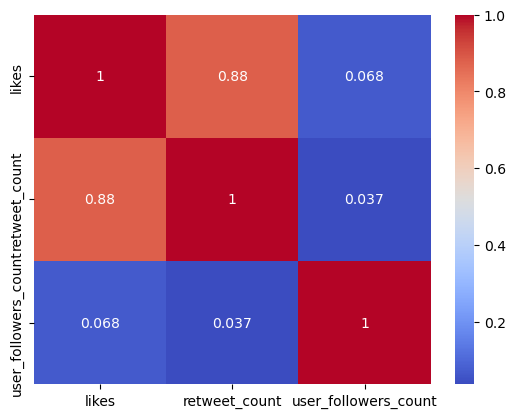

In [16]:
import seaborn as sns
corr = doc[['likes', 'retweet_count', 'user_followers_count']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')


## Correlation Analysis
Examining relationships between engagement metrics and follower count.

> **Finding:**  and  are strongly correlated (0.88), meaning viral tweets tend to get both. Notably,  has almost no correlation with either — having more followers does not guarantee engagement.

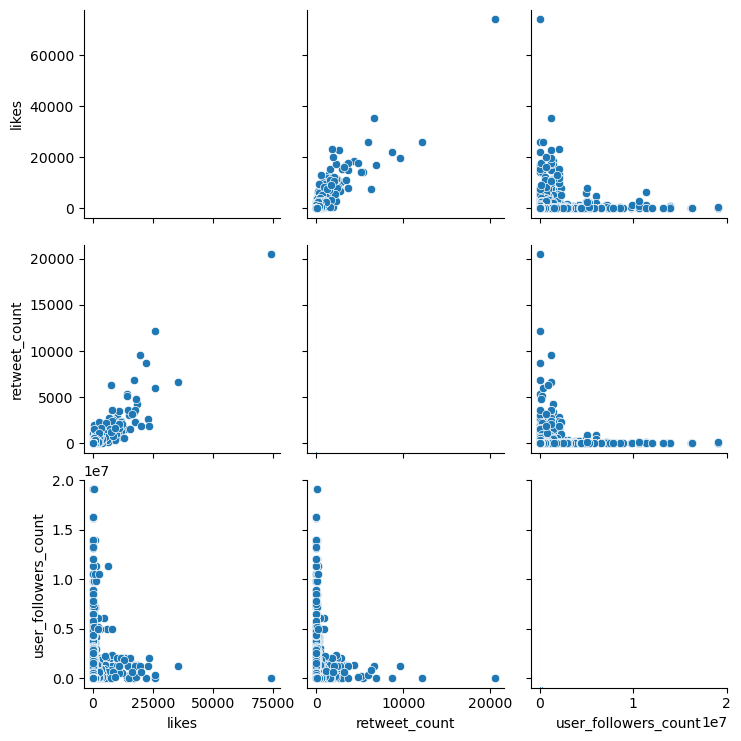

In [17]:
sns.pairplot(doc[['likes', 'retweet_count', 'user_followers_count']])


In [18]:
def scatter2d(X, y):
    fig, ax = plt.subplots(figsize=(15,10))
    colors = colormaps['tab10'].colors

    ax.scatter(X[:,0], X[:,1], c=y, alpha=0.5, cmap='tab10')

    # label a random sample of points
    points = len(y)*sample(100)
    for i in points.astype(int):
        ax.text(X[i,0], X[i,1], y[i], color=colors[int(y[i])], size=16, 
                path_effects=[pe.withStroke(linewidth=2, foreground="white")])
        
def scatter3d(X, y):
    fig = plt.figure(figsize=(15,10))
    ax = fig.add_subplot(111, projection='3d')
    colors = colormaps['tab10'].colors

    ax.mouse_init()
    ax.scatter(X[:,0], X[:,1], X[:,2], c=y, alpha=0.5, cmap='tab10')
    
    # label a random sample of points
    points = len(y)*sample(100)
    for i in points.astype(int):
        ax.text(X[i,0], X[i,1], X[i,2], y[i], color=colors[int(y[i])], size=16, 
                path_effects=[pe.withStroke(linewidth=2, foreground="white")])

## K-Means Clustering
Grouping tweets by engagement behaviour using K-Means. The elbow method is used to determine the optimal number of clusters.

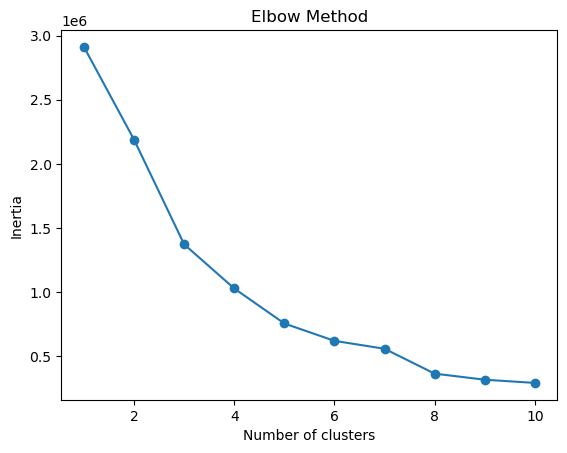

In [19]:
from sklearn.preprocessing import StandardScaler
X=doc[['likes', 'retweet_count', 'user_followers_count']].dropna()
#apparently I need to scale
scaler=StandardScaler()
X_scaled = scaler.fit_transform(X)
inertia = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=0)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.plot(range(1, 11), inertia, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()


In [20]:
kmeans=KMeans(4,random_state=0)
doc_clean=X.copy()
doc_clean['cluster']=kmeans.fit_predict(X_scaled)

In [21]:
doc_clean.groupby('cluster')[['likes', 'retweet_count', 'user_followers_count']].mean()


,likes,retweet_count,user_followers_count
cluster,,,
0,6.290574,1.458645,1.558685e+04
1,11363.345238,2435.035714,9.665875e+05
2,172.998654,12.185734,9.077220e+06
3,74084.000000,20491.000000,8.033000e+03


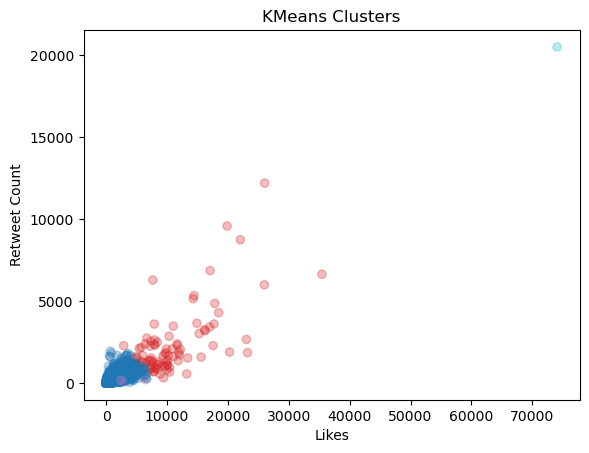

In [22]:
plt.scatter(doc_clean['likes'], doc_clean['retweet_count'], 
            c=doc_clean['cluster'], cmap='tab10', alpha=0.3)
plt.xlabel('Likes')
plt.ylabel('Retweet Count')
plt.title('KMeans Clusters')
plt.show()


## Cluster Interpretation

| Cluster | Description |
|---|---|
| 0 | Low likes, low retweets, low followers — ordinary users, ignored tweets |
| 1 | High followers, low engagement — large accounts whose tweets did not land |
| 2 | High likes, high retweets — viral tweets regardless of follower count |
| 3 | Extreme outliers — potential bots, celebrities, or coordinated activity |

In [23]:
doc[['likes', 'retweet_count', 'user_followers_count']].mean()
# doc[['likes', 'retweet_count', 'user_followers_count']].median()
# doc[['likes', 'retweet_count', 'user_followers_count']].mode()

likes                       7.477011
retweet_count               1.698500
user_followers_count    22603.570878
dtype: float64

In [24]:
doc[['likes', 'retweet_count', 'user_followers_count']].median()

likes                     0.0
retweet_count             0.0
user_followers_count    441.0
dtype: float64

## Central Tendency — Observations
The data is **heavily right-skewed**. The majority of tweets receive zero likes and zero retweets, pulling the median to 0. The mean is inflated by a small number of extremely viral tweets. This is consistent with a **power law distribution** — common in social media engagement.

In [25]:
doc[["likes", "retweet_count", "user_followers_count"]].mode()

,likes,retweet_count,user_followers_count
0,0.0,0.0,0.0


In [26]:
doc[['likes', 'retweet_count', 'user_followers_count']].var()



likes                   2.498237e+04
retweet_count           1.602274e+03
user_followers_count    9.254687e+10
dtype: float64

## Variability
The variance is extremely large across all three metrics, reflecting the massive gap between ordinary tweets and viral ones.

In [27]:
doc[['likes', 'retweet_count', 'user_followers_count']].quantile([0.25, 0.5, 0.75,0.95])


,likes,retweet_count,user_followers_count
0.25,0.0,0.0,77.0
0.50,0.0,0.0,441.0
0.75,1.0,0.0,2066.0
0.95,13.0,3.0,24927.0


## Quantile Analysis
The 95th percentile gives a clearer picture of where the top 5% of tweets sit in terms of engagement — useful for defining a virality threshold.

In [28]:
doc[['likes', 'retweet_count', 'user_followers_count']].max()


likes                      74084.0
retweet_count              20491.0
user_followers_count    19115332.0
dtype: float64

In [29]:
doc[['likes', 'retweet_count', 'user_followers_count']].min()

likes                   0.0
retweet_count           0.0
user_followers_count    0.0
dtype: float64

In [30]:
from scipy import stats
print(stats.skew(doc[['likes', 'retweet_count', 'user_followers_count']]))

[172.03573374 231.07154432  32.44848559]


## Skewness
All three metrics show **strong positive skew**, confirming the distribution is far from normal. Most values cluster near zero with a long right tail driven by outliers.

In [31]:
print(stats.kurtosis(doc[['likes', 'retweet_count', 'user_followers_count']]))

[58168.22266858 89813.52141142  1330.20145923]


## Kurtosis
High kurtosis indicates **extreme outliers** (fat tails). Likes show the highest kurtosis, meaning viral tweet outliers are disproportionately extreme compared to retweets or follower counts.

## Interpretation
 exhibits the most extreme outlier behaviour, suggesting virality in terms of likes is more concentrated in a smaller number of exceptional tweets.

In [32]:
Q1 = doc['likes'].quantile(0.25)
Q3 = doc['likes'].quantile(0.75)
IQR = Q3 - Q1

outliers = doc[(doc['likes'] < Q1 - 1.5*IQR) | (doc['likes'] > Q3 + 1.5*IQR)]
print(f"Number of outliers: {len(outliers)}")

Number of outliers: 169481


In [33]:
Q1 = doc['retweet_count'].quantile(0.25)
Q3 = doc['retweet_count'].quantile(0.75)
IQR = Q3 - Q1

outliers = doc[(doc['retweet_count'] < Q1 - 1.5*IQR) | (doc['retweet_count'] > Q3 + 1.5*IQR)]
print(f"Number of outliers: {len(outliers)}")

Number of outliers: 190843


In [34]:
Q1 = doc['user_followers_count'].quantile(0.25)
Q3 = doc['user_followers_count'].quantile(0.75)
IQR = Q3 - Q1

outliers = doc[(doc['user_followers_count'] < Q1 - 1.5*IQR) | (doc['user_followers_count'] > Q3 + 1.5*IQR)]
print(f"Number of outliers: {len(outliers)}")

Number of outliers: 134553


## Dataset Limitations

- **No ground truth labels** — cannot verify bots or misinformation without external data
- **Median engagement is 0** — distribution is heavily skewed, mean is misleading
- **Follower count does not correlate with engagement** — reach does not equal impact
- **Single hashtag, single time period** — October 2020 US election context limits generalisability
- **No cross-platform data** — cannot compare behaviour across Twitter, Reddit, or Bluesky

## Project Relevance

### Strong Evidence For

**Virality Prediction**
- Virality is rare and extreme (power law, high kurtosis)
-  and  correlate strongly (0.88) — a clear virality signal exists to predict

**Sentiment Clustering → Virality**
- K-Means already shows engagement clusters exist
- Natural next step is adding NLP sentiment as another clustering dimension

**User Segmentation**
- Clusters already segment users by behaviour
- Follower count ≠ engagement is a key finding that shapes how user types are defined

**Bot Detection**
- Extreme outliers in clusters warrant investigation
-  + low followers + high volume = potential bot signal

---

### Partially Supported

**Trend Shifts Around Election**
- Data is October 2020 but tweet volume over time has not been plotted yet
- One temporal plot would strongly support this idea

**Location-Based Perspectives**
- Geographic concentration shown (North America dominant)
- Engagement by location not yet explored —  on likes/retweets would add evidence

---

### Not Well Supported By This Data

- Cross-platform comparison — different datasets needed
- Stock market predictor — requires external financial data
- Misinformation labelling — no ground truth exists in this dataset